In [13]:
#IMPORTS
%matplotlib widget
import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert
from scipy.optimize import curve_fit
import ipywidgets as widgets

#NAMING SETUP
base_dir = Path.cwd().parent / "metingen"      # <-- aangepast: map staat één niveau hoger
assert base_dir.exists(), f"Map niet gevonden: {base_dir}"

position_names = [f"0-{i}" for i in range(1, 5)] + [f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

raw_source_names = numbered_names("usr_wf_C1_data", 3)
fft_source_names = numbered_names("usr_wf_F1_data", 3)

#LENGTHS
length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    return float(match.group(1)) if match else None

#FORCES
g = 9.81
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10}
gewicht_1 = 1.0468
gewicht_2 = 1.0436

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch] + gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

#FOLDER NAMES AND LENGTHS
cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)
length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

#GET SHAPE
def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            for source_name in source_names:
                file_path = cm_folder / f"metingen {position}" / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)
assert raw_shape is not None, "Geen raw csv-bestanden gevonden, controleer mapnamen en bestandsnamen"

#PREALLOCATE + LOAD
n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        for r, source_name in enumerate(raw_source_names):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r] = np.loadtxt(file_path, skiprows=12, delimiter=",")
        for r, source_name in enumerate(fft_source_names):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r] = np.loadtxt(file_path, skiprows=12, delimiter=",")

print("raw_array shape:", raw_array.shape)
print("aandeel NaN in raw_array:", np.isnan(raw_array).mean())

#METADATA GRIDS
length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))*1e-2
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
aandeel NaN in raw_array: 0.0


In [14]:
from pathlib import Path

base_dir = Path.cwd().parent / "metingen"
print("base_dir:", base_dir, "| bestaat:", base_dir.exists())

for f in sorted(base_dir.iterdir())[:4]:
    print("\nmap:", f.name)
    for sub in sorted(f.iterdir())[:3]:
        print("   ", sub.name)
        if sub.is_dir():
            for fi in sorted(sub.iterdir())[:6]:
                print("       ", fi.name)

base_dir: c:\Users\tijnn\Desktop\Studie\Jaar 2\Q1\IP 3\Proef 1\Vibrating-String-Experiment\metingen | bestaat: True

map: metingen 23 cm
    metingen 0-1
        usr_wf_C1_data (1).csv
        usr_wf_C1_data (2).csv
        usr_wf_C1_data.csv
        usr_wf_F1_data (1).csv
        usr_wf_F1_data (2).csv
        usr_wf_F1_data.csv
    metingen 0-2
        usr_wf_C1_data (1).csv
        usr_wf_C1_data (2).csv
        usr_wf_C1_data.csv
        usr_wf_F1_data (1).csv
        usr_wf_F1_data (2).csv
        usr_wf_F1_data.csv
    metingen 0-3
        usr_wf_C1_data (1).csv
        usr_wf_C1_data (2).csv
        usr_wf_C1_data.csv
        usr_wf_F1_data (1).csv
        usr_wf_F1_data (2).csv
        usr_wf_F1_data.csv

map: metingen 25.5 cm
    metingen 0-1
        usr_wf_C1_data (1).csv
        usr_wf_C1_data (2).csv
        usr_wf_C1_data.csv
        usr_wf_F1_data (1).csv
        usr_wf_F1_data (2).csv
        usr_wf_F1_data.csv
    metingen 0-2
        usr_wf_C1_data (1).csv
        usr_

In [15]:
#LENGTHS

length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    if match:
        return float(match.group(1))
    return None

In [16]:
#FORCES

g = 9.81 #m/s
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10} #notch to lever ratio
gewicht_1 = 1.0468 #kg
gewicht_2 = 1.0436 #kg

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch]+gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

In [17]:
#FOLDER NAMES AND LENGTHS

cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)

length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

In [18]:
#GET SHAPE

def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            position_folder = cm_folder / f"metingen {position}"
            for source_name in source_names:
                file_path = position_folder / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)

In [19]:
#PREALLOCATE FINAL ARRAYS

n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

In [20]:
#LOAD FILES INTO ARRAY SLOTS

for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        for r, source_name in enumerate(raw_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")
        for r, source_name in enumerate(fft_source_names, start=1):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r-1] = np.loadtxt(file_path, skiprows=12, delimiter=",")

print("raw_array shape:", raw_array.shape)
print("fft_array shape:", fft_array.shape)

Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
fft_array shape: (5, 8, 3, 4096, 5)


In [21]:
#METADATA GRIDS

length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))*10**-2
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

In [22]:
from pathlib import Path

cwd = Path.cwd()
print("Werkmap:", cwd)
print("Inhoud:", sorted(p.name for p in cwd.iterdir()))

for c in [cwd, *list(cwd.parents)[:3]]:
    for p in c.iterdir():
        if p.is_dir() and "metingen" in p.name.lower():
            print("Gevonden:", p.resolve())

Werkmap: c:\Users\tijnn\Desktop\Studie\Jaar 2\Q1\IP 3\Proef 1\Vibrating-String-Experiment\Amplitude analyse
Inhoud: ['Labjournal_amplitude.ipynb']
Gevonden: C:\Users\tijnn\Desktop\Studie\Jaar 2\Q1\IP 3\Proef 1\Vibrating-String-Experiment\metingen
Gevonden: C:\Users\tijnn\Desktop\Studie\Jaar 2\Q1\IP 3\Proef 1\Vibrating-String-Experiment\Metingen moment 2


In [23]:
#IMPORTS
%matplotlib widget
import re
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, hilbert
from scipy.optimize import curve_fit
import ipywidgets as widgets

#NAMING SETUP

print("Werkmap:", Path.cwd())
print("Map 'metingen' gevonden:", base_dir.exists())
assert base_dir.exists(), "Map 'metingen' staat niet in de werkmap van dit notebook"

position_names = [f"0-{i}" for i in range(1, 5)] + [f"{i}-4" for i in range(1, 5)]

def numbered_names(prefix, count):
    return [prefix] + [f"{prefix} ({i})" for i in range(1, count)]

raw_source_names = numbered_names("usr_wf_C1_data", 3)
fft_source_names = numbered_names("usr_wf_F1_data", 3)

#LENGTHS
length_pattern = re.compile(r"(\d+(?:\.\d+)?)\s*cm")

def parse_length(folder_name):
    match = length_pattern.search(folder_name)
    if match:
        return float(match.group(1))
    return None

#FORCES
g = 9.81
notch_to_ratio = {0: 0, 1: 4, 2: 6, 3: 8, 4: 10}
gewicht_1 = 1.0468
gewicht_2 = 1.0436

def position_force(position):
    w2_notch, w1_notch = (int(n) for n in position.split("-"))
    return gewicht_1*g*notch_to_ratio[w1_notch] + gewicht_2*g*notch_to_ratio[w2_notch]

forces_arr = np.array([position_force(p) for p in position_names], dtype=float)

#FOLDER NAMES AND LENGTHS
cm_folders = sorted(f for f in base_dir.iterdir() if f.is_dir() and "23" not in f.name)
length_names_sorted = [f.name for f in cm_folders]
lengths_arr = np.array([parse_length(name) for name in length_names_sorted])

#GET SHAPE
def find_shape(source_names):
    for cm_folder in cm_folders:
        for position in position_names:
            position_folder = cm_folder / f"metingen {position}"
            for source_name in source_names:
                file_path = position_folder / f"{source_name}.csv"
                if file_path.exists():
                    return np.loadtxt(file_path, skiprows=12, delimiter=",").shape

raw_shape = find_shape(raw_source_names)
fft_shape = find_shape(fft_source_names)
assert raw_shape is not None, "Geen raw csv-bestanden gevonden, controleer mapnamen en bestandsnamen"

#PREALLOCATE FINAL ARRAYS
n_lengths = len(cm_folders)
n_positions = len(position_names)
n_replicates = 3

raw_array = np.full((n_lengths, n_positions, n_replicates, *raw_shape), np.nan)
fft_array = np.full((n_lengths, n_positions, n_replicates, *fft_shape), np.nan)

#LOAD FILES INTO ARRAY SLOTS
for i, cm_folder in enumerate(cm_folders):
    print(f"Processing folder: {cm_folder.name}")
    for j, position in enumerate(position_names):
        position_folder = cm_folder / f"metingen {position}"
        for r, source_name in enumerate(raw_source_names):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                raw_array[i, j, r] = np.loadtxt(file_path, skiprows=12, delimiter=",")
        for r, source_name in enumerate(fft_source_names):
            file_path = position_folder / f"{source_name}.csv"
            if file_path.exists():
                fft_array[i, j, r] = np.loadtxt(file_path, skiprows=12, delimiter=",")

print("raw_array shape:", raw_array.shape)
print("fft_array shape:", fft_array.shape)
print("aandeel NaN in raw_array:", np.isnan(raw_array).mean())

#METADATA GRIDS
length_grid = np.broadcast_to(lengths_arr[:, None], (n_lengths, n_positions))*1e-2
force_grid = np.broadcast_to(forces_arr[None, :], (n_lengths, n_positions))

Werkmap: c:\Users\tijnn\Desktop\Studie\Jaar 2\Q1\IP 3\Proef 1\Vibrating-String-Experiment\Amplitude analyse
Map 'metingen' gevonden: True
Processing folder: metingen 25.5 cm
Processing folder: metingen 27 cm
Processing folder: metingen 28.5 cm
Processing folder: metingen 30 cm
Processing folder: metingen 31.5 cm
raw_array shape: (5, 8, 3, 10000, 2)
fft_array shape: (5, 8, 3, 4096, 5)
aandeel NaN in raw_array: 0.0


In [24]:
#TRIMMING DATA

def manual_trim(margin):
    n_lengths, n_positions, n_replicates, n_samples_raw, n_cols_raw = raw_array.shape
    start_indices = np.zeros((n_lengths, n_positions, n_replicates), dtype=int)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start_indices[i, j, r] = margin

    #every signal keeps the same number of points after its own start, so the result stays rectangular
    trimmed_length = n_samples_raw - start_indices.max()
    raw_trimmed = np.full((n_lengths, n_positions, n_replicates, trimmed_length, n_cols_raw), np.nan)

    for i in range(n_lengths):
        for j in range(n_positions):
            for r in range(n_replicates):
                start = start_indices[i, j, r]
                if start >= n_samples_raw:
                    continue
                raw_trimmed[i, j, r] = raw_array[i, j, r, start:start + trimmed_length, :]

    return raw_trimmed, trimmed_length

In [25]:
# --- THEORIE ---
C_w = 1.2          # drag coefficient (aanname)
rho = 1.204        # dichtheid lucht (kg/m^3)
D = 0.001          # diameter snaar (m)
rho_s = 7900       # dichtheid staal (kg/m^3)
mu = (D/2)**2 * np.pi * rho_s   # lineaire massadichtheid (kg/m)
n = 1              # modenummer
U_0 = 0.5          # default begin-amplitude

T_array = forces_arr   # zelfde spanningen als in de krachtencel (volgorde 0-1..0-4, 1-4..4-4)

def alpha_theory(L, T):
    return (2*C_w*rho*D*n/(3*mu*L**2))*np.sqrt(T/mu)

def theory_amp(t, alpha, U0=U_0):
    return U0 / (alpha*U0*t + 1)

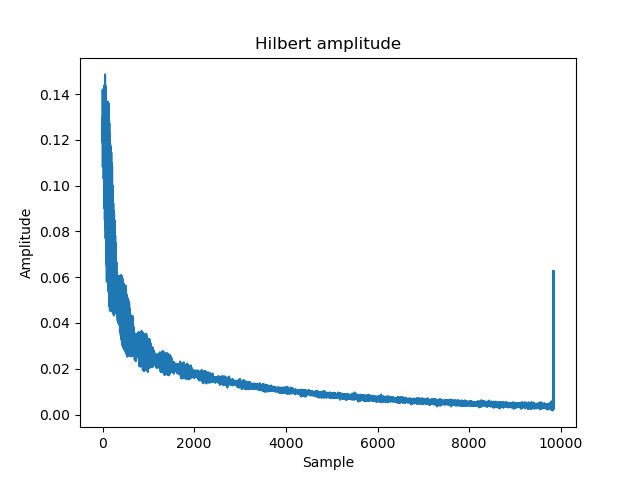

In [26]:
raw_trim , trim_L = manual_trim(160)

i = 0   # eerste lengte
j = 0   # eerste positie
r = 0   # eerste replicaat
col = 1 # kolom met het signaal

signal = raw_trim[i, j, r, :, col]
analytic = hilbert(signal)
amplitude = np.abs(analytic)

plt.plot(amplitude)
plt.title("Hilbert amplitude")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

T=41.1 N: alpha_theory = 194, alpha_fit = 664
T=61.6 N: alpha_theory = 238, alpha_fit = 273
T=82.2 N: alpha_theory = 275, alpha_fit = 397
T=102.7 N: alpha_theory = 307, alpha_fit = 574
T=143.6 N: alpha_theory = 363, alpha_fit = 354
T=164.1 N: alpha_theory = 388, alpha_fit = 323
T=184.6 N: alpha_theory = 412, alpha_fit = 237
T=205.1 N: alpha_theory = 434, alpha_fit = 187


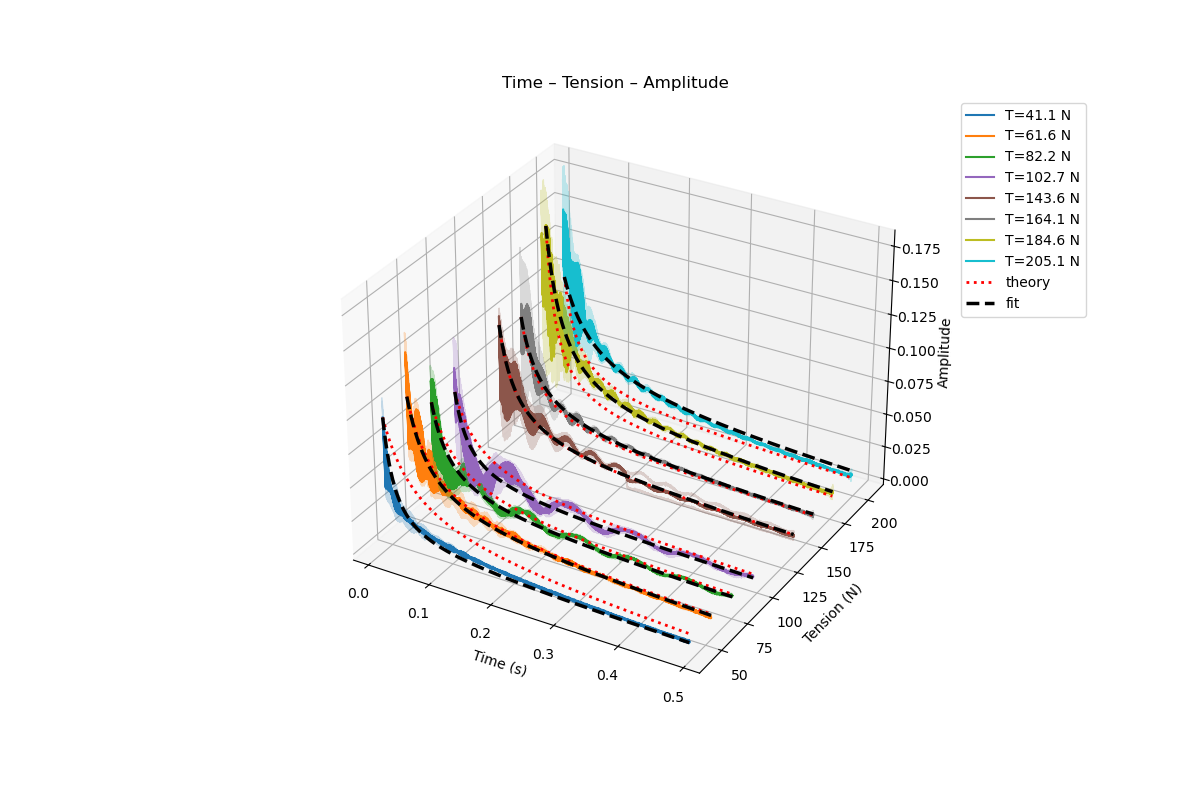

L=0.255 m: alpha_theory = 194, alpha_fit = 664
L=0.270 m: alpha_theory = 173, alpha_fit = 430
L=0.285 m: alpha_theory = 156, alpha_fit = 484
L=0.300 m: alpha_theory = 140, alpha_fit = 353
L=0.315 m: alpha_theory = 127, alpha_fit = 332


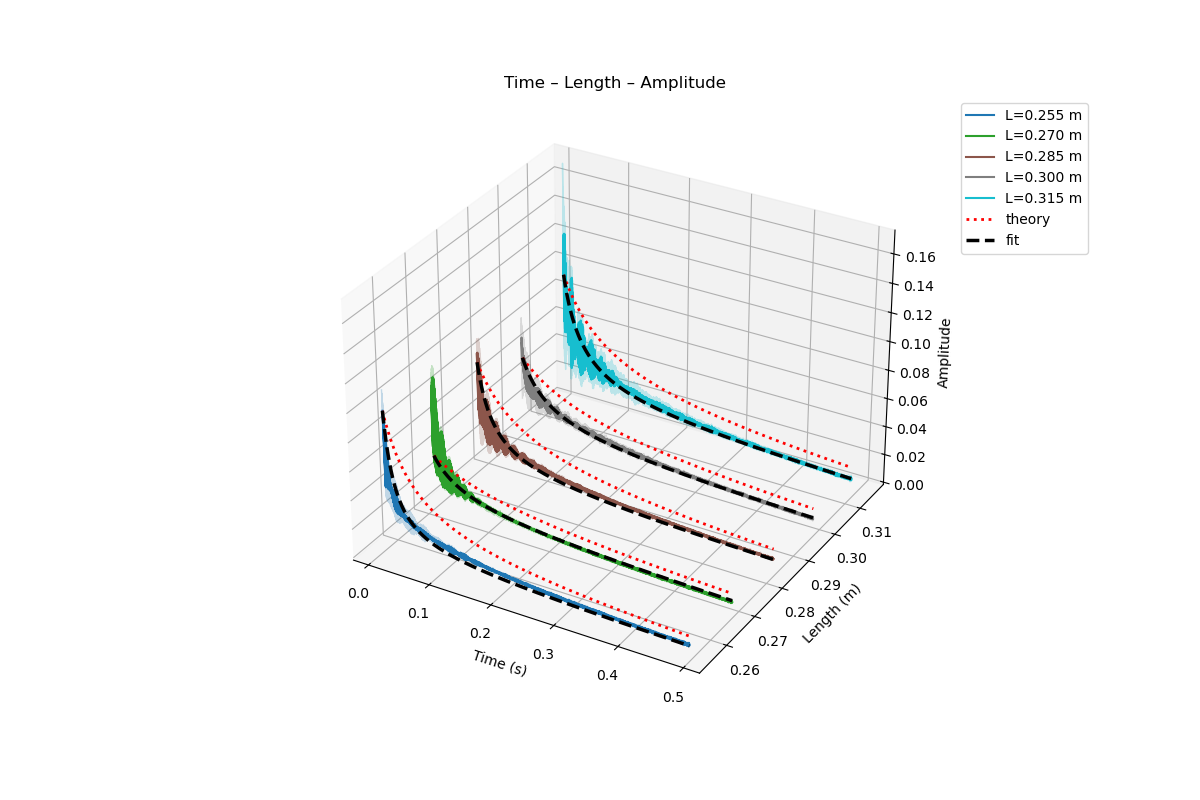

In [27]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit
from scipy.signal import hilbert

fs = 20000
start_trim = 200     # samples removed at start (Hilbert edge effect)
end_trim = 50        # samples removed at end
peak_window = 4000   # first peak is searched within this many samples after start_trim
smooth_n = 51        # smoothing width used only to locate the peak


def get_envelope(i, j):
    """Mean/std Hilbert envelope over replicates (skips replicates with NaNs)."""
    envs = []
    for r in range(n_replicates):
        sig = raw_trim[i, j, r, :, 1]
        if np.all(np.isfinite(sig)):
            envs.append(np.abs(hilbert(sig)))
    if not envs:
        return None
    envs = np.array(envs)
    t = np.arange(envs.shape[1]) / fs
    sl = slice(start_trim, -end_trim)
    return t[sl], envs.mean(axis=0)[sl], envs.std(axis=0)[sl]


def analyse(i, j):
    out = get_envelope(i, j)
    if out is None:
        return None
    t, mean, std = out

    # first peak of the envelope
    k = int(np.argmax(uniform_filter1d(mean, smooth_n, mode="nearest")[:peak_window]))
    U0 = mean[k]
    t_rel = t[k:] - t[k]          # time since the peak

    alpha_th = alpha_theory(length_grid[i, j], T_array[j])

    # fit only alpha; U0 is fixed to the peak so fit and theory start on the data
    try:
        popt, _ = curve_fit(lambda tt, a: theory_amp(tt, a, U0),
                            t_rel, mean[k:], p0=[alpha_th], bounds=(0, np.inf))
        alpha_fit = popt[0]
    except RuntimeError:
        alpha_fit = np.nan

    return dict(t=t, mean=mean, std=std, k=k, U0=U0, t_rel=t_rel,
                alpha_th=alpha_th, alpha_fit=alpha_fit)


def plot_3d(pairs, y_vals, ylabel, labels, title):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
    colors = plt.cm.tab10(np.linspace(0, 1, len(pairs)))

    for col, (i, j), y, lab in zip(colors, pairs, y_vals, labels):
        res = analyse(i, j)
        if res is None:
            continue
        t, mean, std, k = res["t"], res["mean"], res["std"], res["k"]

        # data + std band (bottom layer)
        y_line = np.full_like(t, y)
        ax.plot(t, y_line, mean, color=col, lw=1.5, zorder=1, label=lab)
        ax.plot(t, y_line, mean + std, color=col, alpha=0.25, lw=1, zorder=1)
        ax.plot(t, y_line, mean - std, color=col, alpha=0.25, lw=1, zorder=1)

        # theory + fit, both starting on the first peak
        t_pk = t[k:]
        y_pk = np.full_like(t_pk, y)
        ax.plot(t_pk, y_pk, theory_amp(res["t_rel"], res["alpha_th"], res["U0"]),
                color="red", ls=":", lw=2, zorder=2)
        if np.isfinite(res["alpha_fit"]):
            ax.plot(t_pk, y_pk, theory_amp(res["t_rel"], res["alpha_fit"], res["U0"]),
                    color="black", ls="--", lw=2.5, zorder=3)   # drawn on top

        print(f"{lab}: alpha_theory = {res['alpha_th']:.3g}, alpha_fit = {res['alpha_fit']:.3g}")

    handles, _ = ax.get_legend_handles_labels()
    handles += [Line2D([0], [0], color="red", ls=":", lw=2),
                Line2D([0], [0], color="black", ls="--", lw=2.5)]
    names = [h.get_label() for h in handles[:-2]] + ["theory", "fit"]
    ax.legend(handles, names, loc="upper left", bbox_to_anchor=(1.05, 1))

    ax.set_xlabel("Time (s)")
    ax.set_ylabel(ylabel)
    ax.set_zlabel("Amplitude")
    ax.set_title(title)
    plt.show()


# 3D plot 1: time - tension - amplitude (fixed length)
i0 = 0
plot_3d(pairs=[(i0, j) for j in range(n_positions)],
        y_vals=T_array,
        ylabel="Tension (N)",
        labels=[f"T={T:.1f} N" for T in T_array],
        title="Time – Tension – Amplitude")

# 3D plot 2: time - length - amplitude (fixed tension)
j0 = 0
plot_3d(pairs=[(i, j0) for i in range(n_lengths)],
        y_vals=length_grid[:, j0],
        ylabel="Length (m)",
        labels=[f"L={length_grid[i, j0]:.3f} m" for i in range(n_lengths)],
        title="Time – Length – Amplitude")

,length_m,tension_N,U0,t_peak_s,alpha_theory,alpha_fit,alpha_fit_se,R2,RMSE,n_replicates,alpha_rep_mean,alpha_rep_std,fit_over_theory,tau_fit_s,position,folder
0,0.255,41.08,0.09881,0.01,194.2,663.7,3.16,0.8096,0.004526,3,663.1,92.88,3.417,0.01525,0-1,metingen 25.5 cm
1,0.255,61.61,0.1,0.01,237.9,273.2,0.8589,0.9342,0.0044,3,274.4,55.15,1.148,0.03659,0-2,metingen 25.5 cm
2,0.255,82.15,0.0819,0.01,274.7,396.9,2.133,0.7936,0.005741,3,397.3,56.16,1.445,0.03076,0-3,metingen 25.5 cm
3,0.255,102.7,0.07569,0.01,307.1,574.4,3.929,0.7543,0.005976,3,571.4,41.61,1.87,0.023,0-4,metingen 25.5 cm
4,0.255,143.6,0.09915,0.01,363.2,354,1.793,0.8287,0.006349,3,356.1,61.49,0.9744,0.02849,1-4,metingen 25.5 cm
5,0.255,164.1,0.09206,0.01,388.3,322.9,0.923,0.9558,0.00356,3,303.8,155.6,0.8316,0.03364,2-4,metingen 25.5 cm
6,0.255,184.6,0.149,0.0172,411.8,237.2,0.8949,0.9051,0.007074,3,237.6,28.7,0.5761,0.02829,3-4,metingen 25.5 cm
7,0.255,205.1,0.09699,0.01125,434,187.2,0.8285,0.9137,0.006982,3,184.4,55.89,0.4314,0.05507,4-4,metingen 25.5 cm
8,0.27,41.08,0.04131,0.0113,173.3,429.9,2.958,0.8116,0.00466,3,430.8,25.32,2.481,0.0563,0-1,metingen 27 cm
9,0.27,61.61,0.1004,0.01135,212.2,412.8,1.653,0.8631,0.004737,3,413,14.17,1.945,0.02413,0-2,metingen 27 cm


alpha_fit:  p (length) = -1.606 ± 0.634  (theory -2),  q (tension) = -0.272 ± 0.089  (theory +0.5),  N = 40
alpha_theory:  p (length) = -2.000 ± 0.000  (theory -2),  q (tension) = 0.500 ± 0.000  (theory +0.5),  N = 40


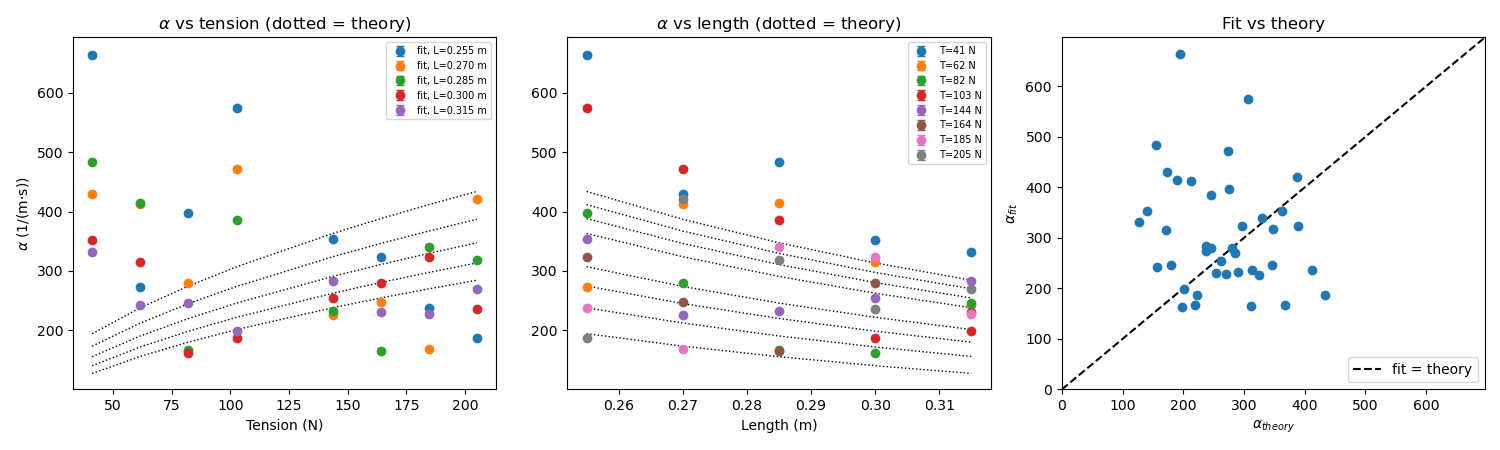

Saved: damping_results.csv, envelopes_all.csv, damping_summary.png


In [28]:
import pandas as pd

def fit_alpha(t_rel, y, alpha0, U0):
    """Fit alpha with U0 fixed. Returns alpha, standard error, R², RMSE."""
    try:
        popt, pcov = curve_fit(lambda tt, a: theory_amp(tt, a, U0),
                               t_rel, y, p0=[alpha0], bounds=(0, np.inf))
    except (RuntimeError, ValueError):
        return np.nan, np.nan, np.nan, np.nan
    resid = y - theory_amp(t_rel, popt[0], U0)
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((y - y.mean())**2)
    return popt[0], np.sqrt(pcov[0, 0]), 1 - ss_res/ss_tot, np.sqrt(np.mean(resid**2))


def analyse_full(i, j):
    res = analyse(i, j)                      # your existing function (mean envelope, peak k, U0)
    if res is None:
        return None
    k, U0, t_rel = res["k"], res["U0"], res["t_rel"]
    alpha_th = res["alpha_th"]

    # fit on the mean envelope
    a_fit, a_se, r2, rmse = fit_alpha(t_rel, res["mean"][k:], alpha_th, U0)

    # fit each replicate separately -> spread between measurements
    rep_alphas = []
    for r in range(n_replicates):
        sig = raw_trim[i, j, r, :, 1]
        if not np.all(np.isfinite(sig)):
            continue
        env = np.abs(hilbert(sig))[start_trim:-end_trim]
        a_r, *_ = fit_alpha(t_rel, env[k:], alpha_th, env[k])
        rep_alphas.append(a_r)
    rep_alphas = np.array(rep_alphas)

    return {
        "length_m": length_grid[i, j],
        "tension_N": T_array[j],
        "U0": U0,
        "t_peak_s": res["t"][k],
        "alpha_theory": alpha_th,
        "alpha_fit": a_fit,
        "alpha_fit_se": a_se,
        "R2": r2,
        "RMSE": rmse,
        "n_replicates": len(rep_alphas),
        "alpha_rep_mean": np.nanmean(rep_alphas) if len(rep_alphas) else np.nan,
        "alpha_rep_std": np.nanstd(rep_alphas, ddof=1) if len(rep_alphas) > 1 else np.nan,
        "fit_over_theory": a_fit / alpha_th,
        "tau_fit_s": 1/(a_fit*U0) if a_fit > 0 else np.nan,   # time for amplitude to halve = 1/(alpha*U0)
    }


# ---- run over ALL length/tension combinations ----
rows = []
for i in range(n_lengths):
    for j in range(n_positions):
        out = analyse_full(i, j)
        if out is not None:
            out["position"] = position_names[j]
            out["folder"] = length_names_sorted[i]
            rows.append(out)

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
display(df)
df.to_csv("damping_results.csv", index=False)


# ---- global scaling: alpha = c * L^p * T^q  ->  ln a = ln c + p ln L + q ln T ----
def scaling_fit(alpha_col):
    d = df.dropna(subset=[alpha_col])
    d = d[d[alpha_col] > 0]
    X = np.column_stack([np.ones(len(d)), np.log(d.length_m), np.log(d.tension_N)])
    y = np.log(d[alpha_col])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    dof = len(y) - 3
    s2 = np.sum((y - X @ beta)**2) / dof
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    print(f"{alpha_col}:  p (length) = {beta[1]:.3f} ± {se[1]:.3f}  (theory -2),"
          f"  q (tension) = {beta[2]:.3f} ± {se[2]:.3f}  (theory +0.5),  N = {len(y)}")

scaling_fit("alpha_fit")
scaling_fit("alpha_theory")   # sanity check: should give exactly -2 and 0.5


# ---- summary figures for the report ----
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

for L, g_ in df.groupby("length_m"):
    axs[0].errorbar(g_.tension_N, g_.alpha_fit, yerr=g_.alpha_fit_se, fmt="o", capsize=3,
                    label=f"fit, L={L:.3f} m")
    axs[0].plot(g_.tension_N, g_.alpha_theory, "k:", lw=1)
axs[0].set(xlabel="Tension (N)", ylabel=r"$\alpha$ (1/(m$\cdot$s))", title=r"$\alpha$ vs tension (dotted = theory)")
axs[0].legend(fontsize=7)

for T, g_ in df.groupby("tension_N"):
    axs[1].errorbar(g_.length_m, g_.alpha_fit, yerr=g_.alpha_fit_se, fmt="o", capsize=3,
                    label=f"T={T:.0f} N")
    axs[1].plot(g_.length_m, g_.alpha_theory, "k:", lw=1)
axs[1].set(xlabel="Length (m)", title=r"$\alpha$ vs length (dotted = theory)")
axs[1].legend(fontsize=7)

axs[2].errorbar(df.alpha_theory, df.alpha_fit, yerr=df.alpha_fit_se, fmt="o", capsize=3)
lim = [0, max(df.alpha_theory.max(), df.alpha_fit.max())*1.05]
axs[2].plot(lim, lim, "k--", label="fit = theory")
axs[2].set(xlabel=r"$\alpha_{theory}$", ylabel=r"$\alpha_{fit}$", title="Fit vs theory", xlim=lim, ylim=lim)
axs[2].legend()

plt.tight_layout()
fig.savefig("damping_summary.png", dpi=300)
plt.show()


# ---- export the envelope curves behind every graph (long format) ----
env_rows = []
for i in range(n_lengths):
    for j in range(n_positions):
        res = analyse(i, j)
        if res is None:
            continue
        k = res["k"]
        n_pts = len(res["t"])
        env_rows.append(pd.DataFrame({
            "length_m": length_grid[i, j], "tension_N": T_array[j],
            "t_s": res["t"], "amp_mean": res["mean"], "amp_std": res["std"],
            "theory": np.r_[np.full(k, np.nan), theory_amp(res["t_rel"], res["alpha_th"], res["U0"])],
            "fit": np.r_[np.full(k, np.nan), theory_amp(res["t_rel"], analyse_full(i, j)["alpha_fit"], res["U0"])],
        }))
pd.concat(env_rows).to_csv("envelopes_all.csv", index=False)
print("Saved: damping_results.csv, envelopes_all.csv, damping_summary.png")